<a href="https://www.kaggle.com/code/lalit7881/tea-vs-coffee-insights-eda?scriptVersionId=307843130" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/global-tea-vs-coffee-lifestyle-dataset/tea_vs_coffee_global_final.csv


## Loading dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mdmahfuzsumon/global-tea-vs-coffee-lifestyle-dataset/tea_vs_coffee_global_final.csv')

In [3]:
df.head()

,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,Bangladesh,Asia,2015,56,Male,Low,Coffee,Mocha,Modern,2.3,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
1,Bangladesh,Asia,2015,61,Other,High,Tea,Oolong Tea,Traditional,1.3,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2,Bangladesh,Asia,2015,59,Female,Low,Coffee,Americano,Modern,3.2,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
3,Bangladesh,Asia,2015,41,Other,High,Coffee,Cappuccino,Modern,3.0,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
4,Bangladesh,Asia,2015,43,Other,Middle,Tea,Green Tea,Traditional,1.9,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


In [4]:
df.tail()

,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
14995,Egypt,Africa,2024,50,Female,High,Coffee,Americano,Modern,2.8,...,Moderate,34.6,9,63,Habit,Work,Morning,Brand Loyal,Yes,1
14996,Egypt,Africa,2024,35,Female,Low,Tea,Masala Chai,Traditional,3.1,...,High,27.8,2,72,Habit,Family,Morning,Brand Loyal,No,5
14997,Egypt,Africa,2024,39,Male,Low,Coffee,Flat White,Modern,4.0,...,High,34.7,4,81,Social,Work,Afternoon,Explorer,No,6
14998,Egypt,Africa,2024,45,Male,Middle,Tea,Milk Tea,Traditional,2.3,...,Low,20.4,2,69,Taste,Friends,Evening,Brand Loyal,No,6
14999,Egypt,Africa,2024,51,Other,Middle,Coffee,Mocha,Modern,4.0,...,Moderate,29.5,1,83,Habit,Alone,Night,Brand Loyal,No,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                15000 non-null  object 
 1   continent              15000 non-null  object 
 2   year                   15000 non-null  int64  
 3   age                    15000 non-null  int64  
 4   gender                 15000 non-null  object 
 5   income_level           15000 non-null  object 
 6   drink_preference       15000 non-null  object 
 7   favorite_drink         15000 non-null  object 
 8   drink_category         15000 non-null  object 
 9   cups_per_day           15000 non-null  float64
 10  drink_temperature      15000 non-null  object 
 11  sugar_level            15000 non-null  object 
 12  milk_usage             15000 non-null  object 
 13  caffeine_preference    15000 non-null  object 
 14  taste_score            15000 non-null  float64
 15  bi

In [6]:
df.describe()

,year,age,cups_per_day,taste_score,bitterness,acidity,aroma_score,monthly_spend,price_per_cup,home_vs_cafe_ratio,sleep_hours,stress_level,bmi,hydration_level,heart_rate,satisfaction_level
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2019.500000,41.115933,2.510380,5.528420,5.507433,5.541207,5.501993,51.904985,5.469805,0.499792,7.004740,4.997133,26.478900,4.990933,79.469733,5.028333
std,2.872377,13.495386,0.993814,2.589166,2.600703,2.593605,2.585103,27.426476,2.594899,0.289961,1.502331,2.578831,4.914655,2.583608,11.569253,2.572646
min,2015.000000,18.000000,0.000000,1.000000,1.000000,1.000000,1.000000,5.010000,1.000000,0.000000,0.400000,1.000000,18.000000,1.000000,60.000000,1.000000
25%,2017.000000,30.000000,1.800000,3.300000,3.300000,3.300000,3.300000,28.120000,3.230000,0.250000,6.000000,3.000000,22.200000,3.000000,69.000000,3.000000
50%,2019.500000,41.000000,2.500000,5.500000,5.500000,5.600000,5.500000,51.430000,5.440000,0.500000,7.000000,5.000000,26.400000,5.000000,79.000000,5.000000
75%,2022.000000,53.000000,3.200000,7.800000,7.800000,7.800000,7.700000,75.650000,7.710000,0.750000,8.000000,7.000000,30.700000,7.000000,89.000000,7.000000
max,2024.000000,64.000000,6.000000,10.000000,10.000000,10.000000,10.000000,100.000000,10.000000,1.000000,13.900000,9.000000,35.000000,9.000000,99.000000,9.000000


In [7]:
df.columns 

Index(['country', 'continent', 'year', 'age', 'gender', 'income_level',
       'drink_preference', 'favorite_drink', 'drink_category', 'cups_per_day',
       'drink_temperature', 'sugar_level', 'milk_usage', 'caffeine_preference',
       'taste_score', 'bitterness', 'acidity', 'aroma_score', 'monthly_spend',
       'price_per_cup', 'home_vs_cafe_ratio', 'work_type', 'sleep_hours',
       'stress_level', 'exercise_frequency', 'bmi', 'hydration_level',
       'heart_rate', 'drink_reason', 'social_setting', 'time_of_day',
       'loyalty_brand', 'experiment_new_drinks', 'satisfaction_level'],
      dtype='object')

In [8]:
df.isnull().sum()

country                  0
continent                0
year                     0
age                      0
gender                   0
income_level             0
drink_preference         0
favorite_drink           0
drink_category           0
cups_per_day             0
drink_temperature        0
sugar_level              0
milk_usage               0
caffeine_preference      0
taste_score              0
bitterness               0
acidity                  0
aroma_score              0
monthly_spend            0
price_per_cup            0
home_vs_cafe_ratio       0
work_type                0
sleep_hours              0
stress_level             0
exercise_frequency       0
bmi                      0
hydration_level          0
heart_rate               0
drink_reason             0
social_setting           0
time_of_day              0
loyalty_brand            0
experiment_new_drinks    0
satisfaction_level       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

country                   object
continent                 object
year                       int64
age                        int64
gender                    object
income_level              object
drink_preference          object
favorite_drink            object
drink_category            object
cups_per_day             float64
drink_temperature         object
sugar_level               object
milk_usage                object
caffeine_preference       object
taste_score              float64
bitterness               float64
acidity                  float64
aroma_score              float64
monthly_spend            float64
price_per_cup            float64
home_vs_cafe_ratio       float64
work_type                 object
sleep_hours              float64
stress_level               int64
exercise_frequency        object
bmi                      float64
hydration_level            int64
heart_rate                 int64
drink_reason              object
social_setting            object
time_of_da

In [11]:
df.shape

(15000, 34)

In [12]:
df.nunique()

country                    15
continent                   5
year                       10
age                        47
gender                      3
income_level                3
drink_preference            2
favorite_drink             15
drink_category              2
cups_per_day               61
drink_temperature           3
sugar_level                 4
milk_usage                  4
caffeine_preference         3
taste_score                91
bitterness                 91
acidity                    91
aroma_score                91
monthly_spend            7538
price_per_cup             901
home_vs_cafe_ratio        101
work_type                   4
sleep_hours               109
stress_level                9
exercise_frequency          3
bmi                       171
hydration_level             9
heart_rate                 40
drink_reason                4
social_setting              4
time_of_day                 4
loyalty_brand               2
experiment_new_drinks       2
satisfacti

## EDA

(15000, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                15000 non-null  object 
 1   continent              15000 non-null  object 
 2   year                   15000 non-null  int64  
 3   age                    15000 non-null  int64  
 4   gender                 15000 non-null  object 
 5   income_level           15000 non-null  object 
 6   drink_preference       15000 non-null  object 
 7   favorite_drink         15000 non-null  object 
 8   drink_category         15000 non-null  object 
 9   cups_per_day           15000 non-null  float64
 10  drink_temperature      15000 non-null  object 
 11  sugar_level            15000 non-null  object 
 12  milk_usage             15000 non-null  object 
 13  caffeine_preference    15000 non-null  object 
 14  taste_score            15000 non-null  flo

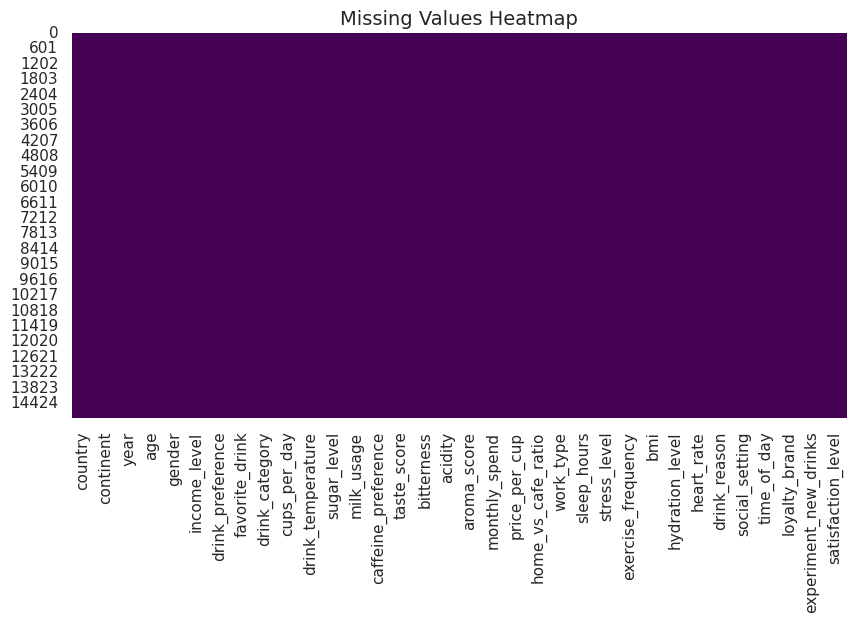

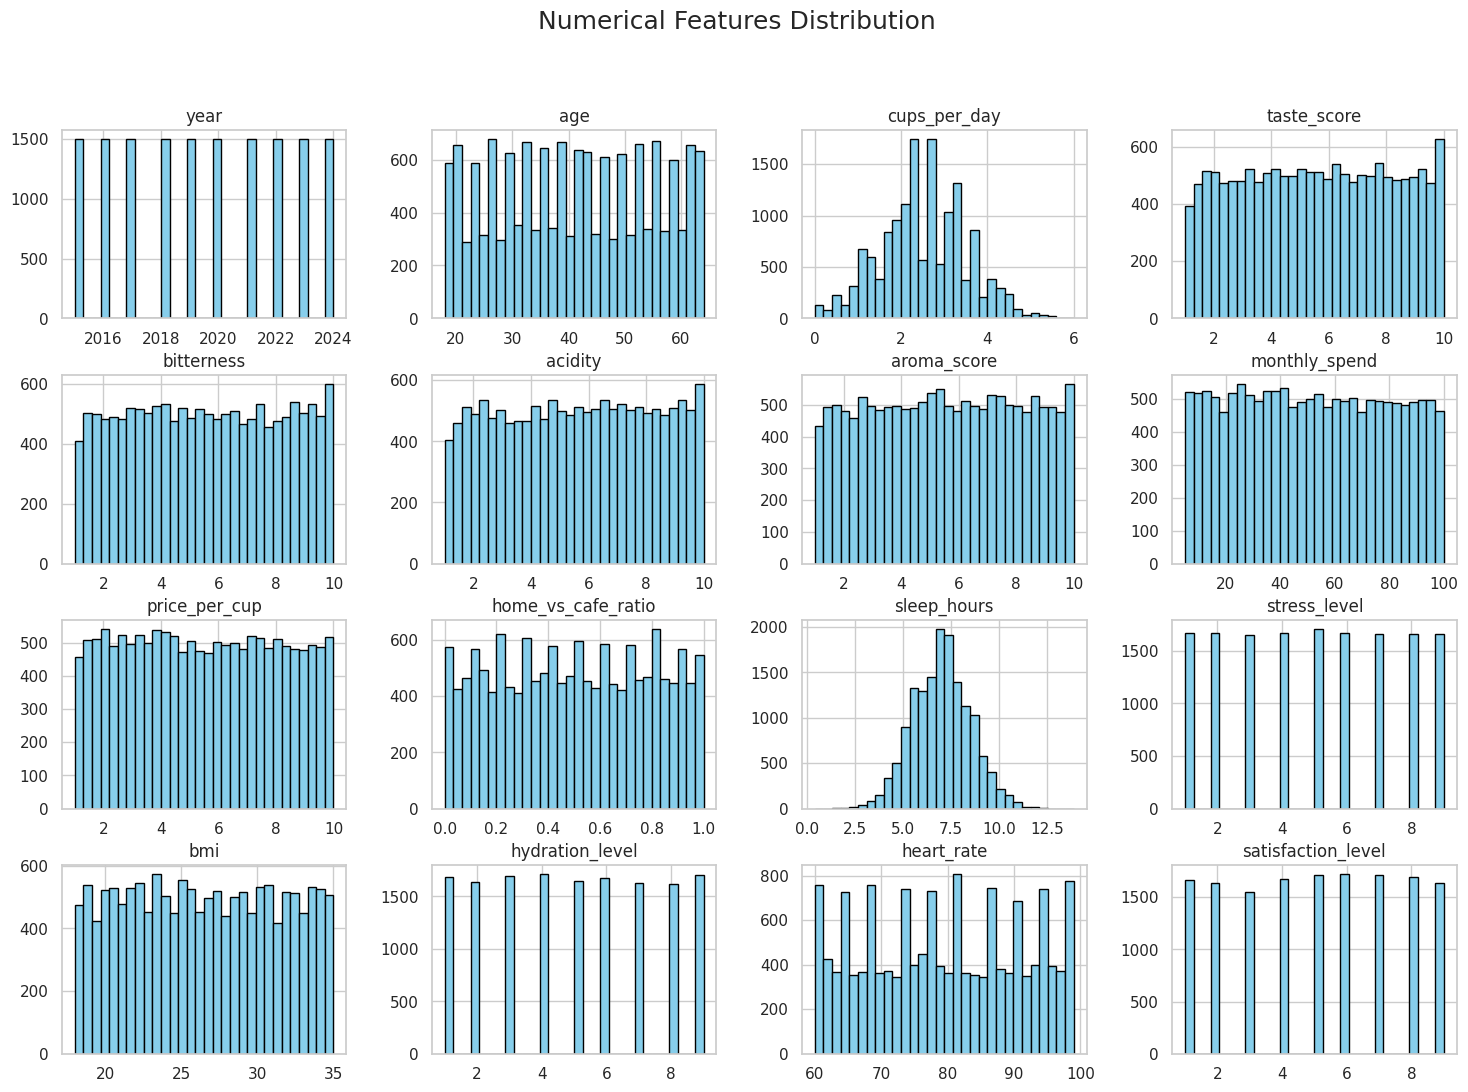

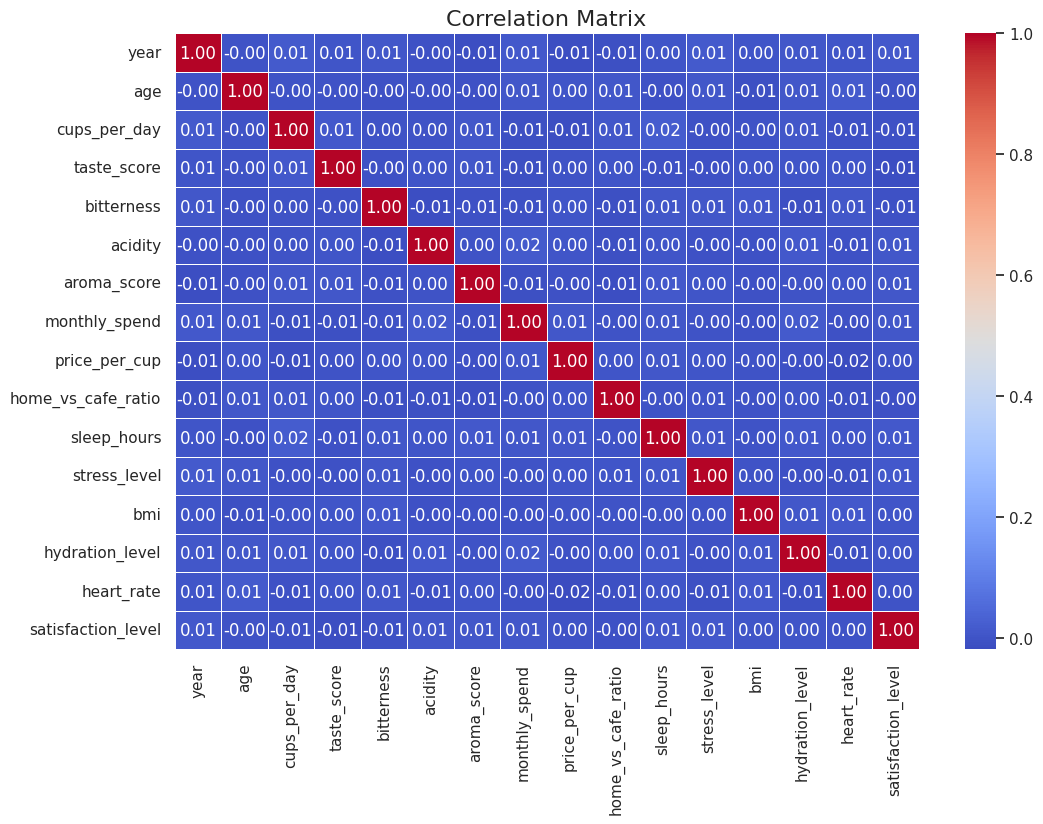

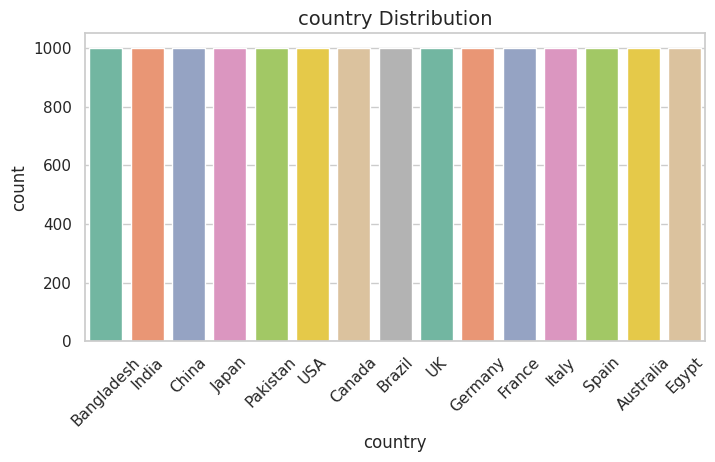

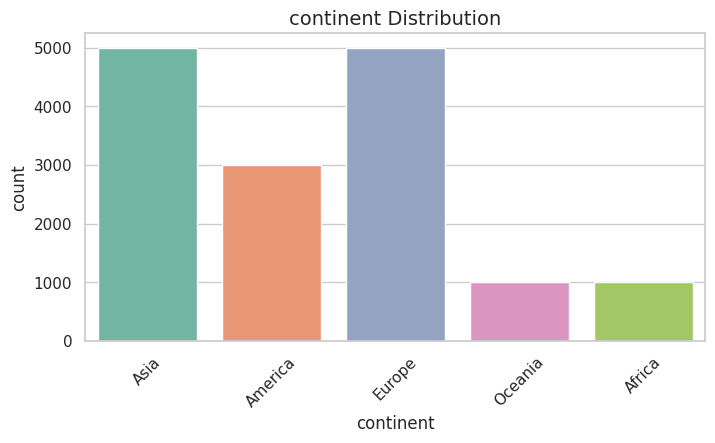

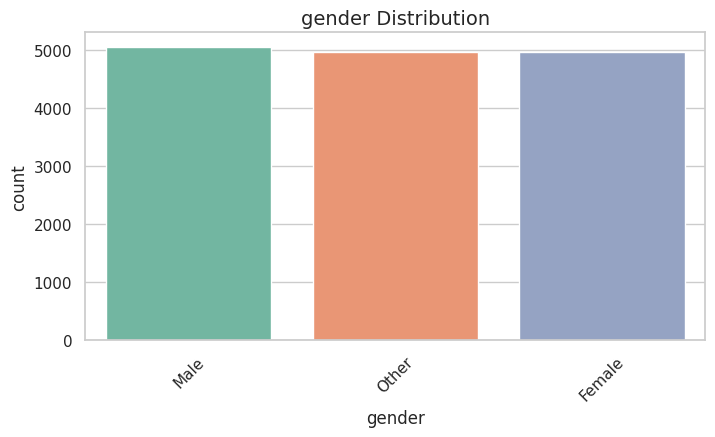

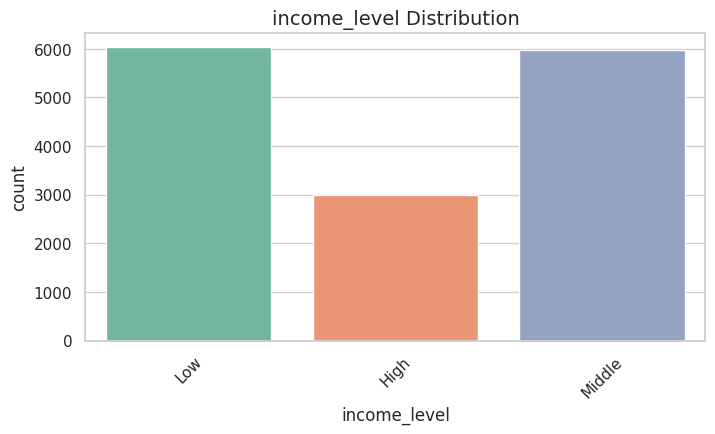

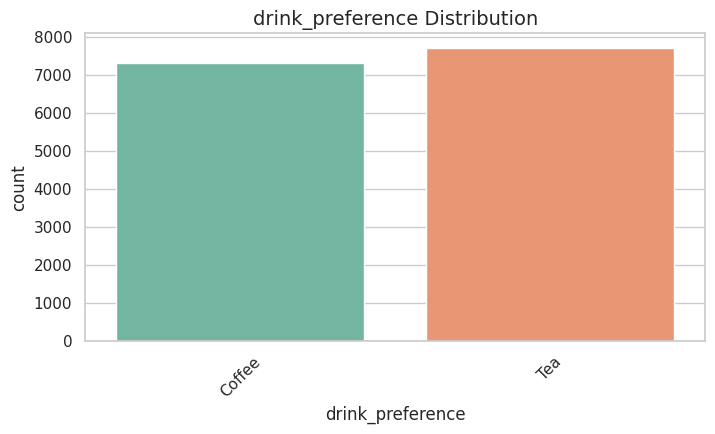

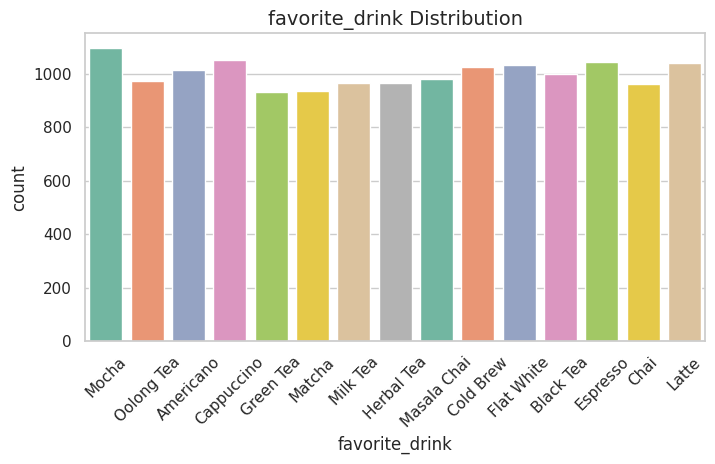

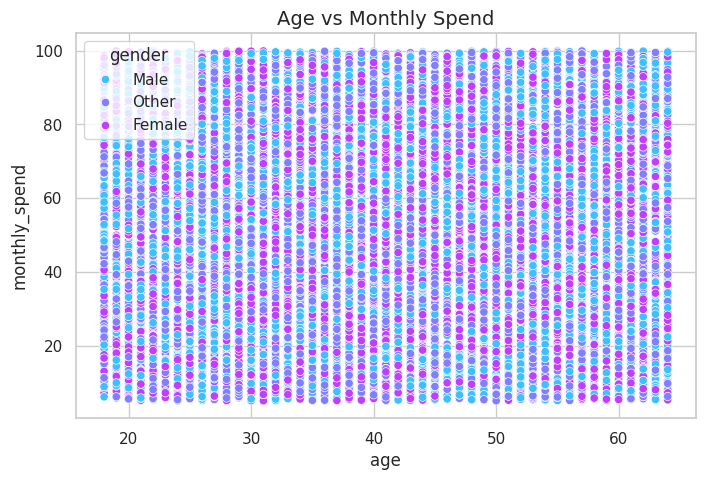

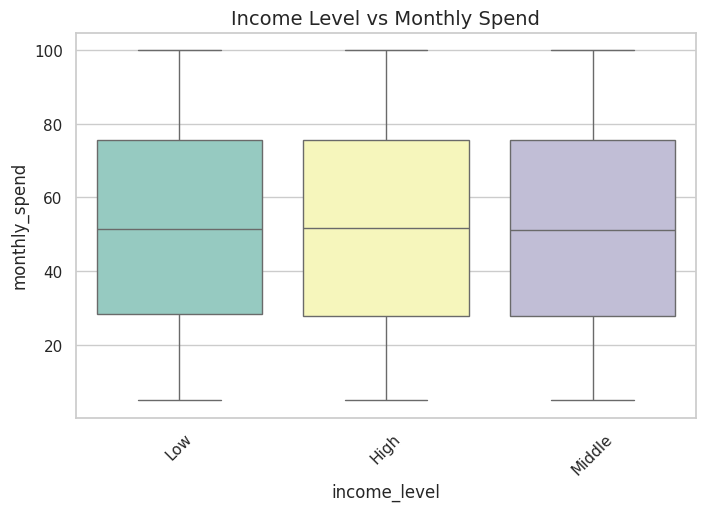

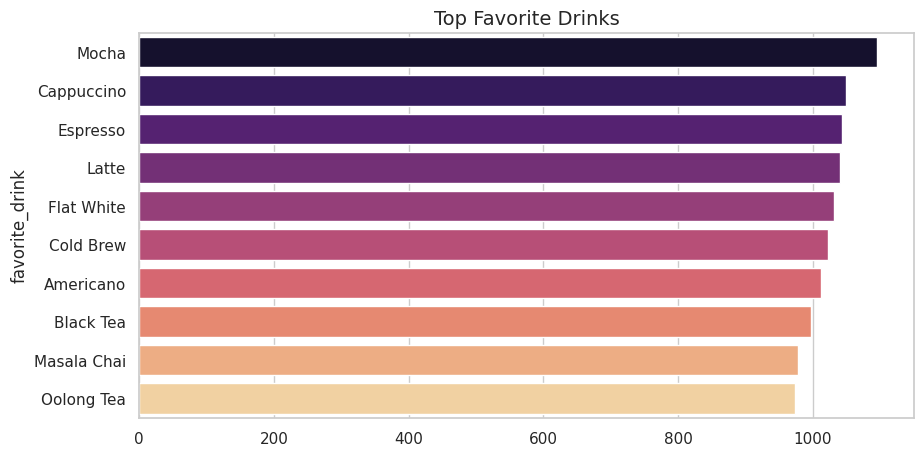

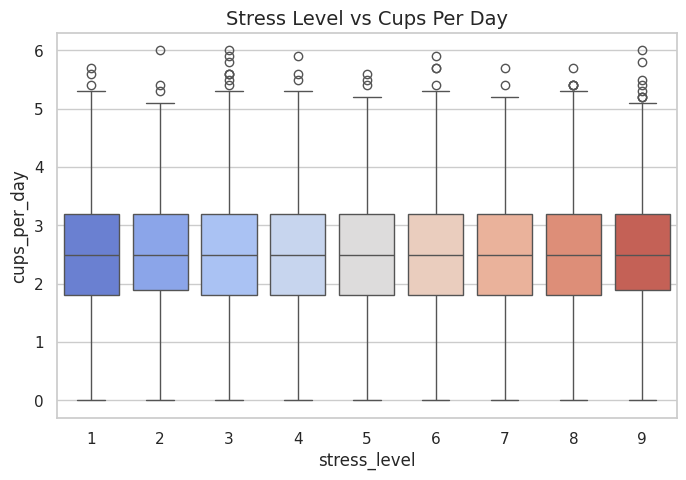

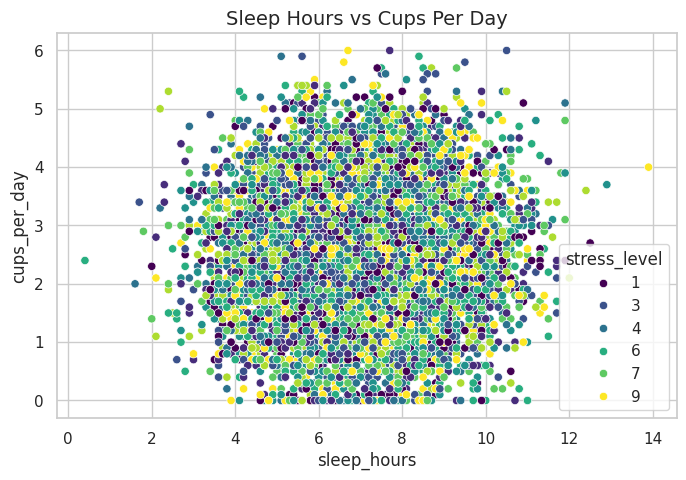

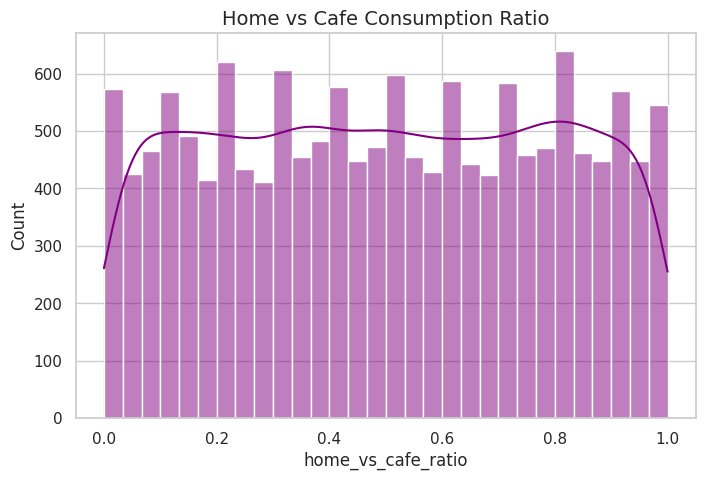

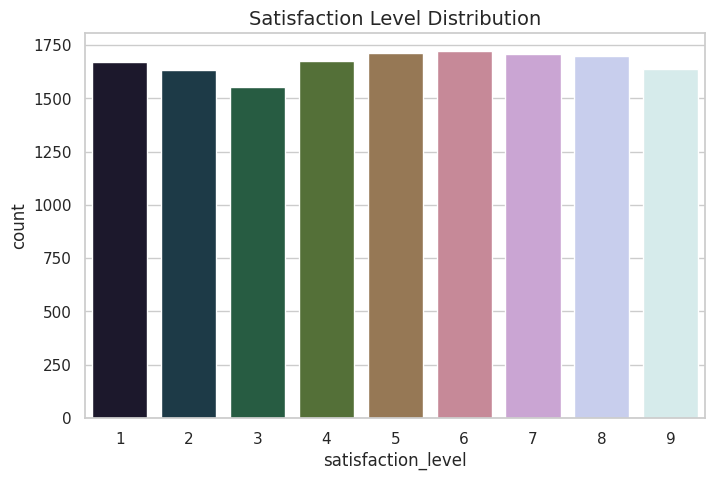

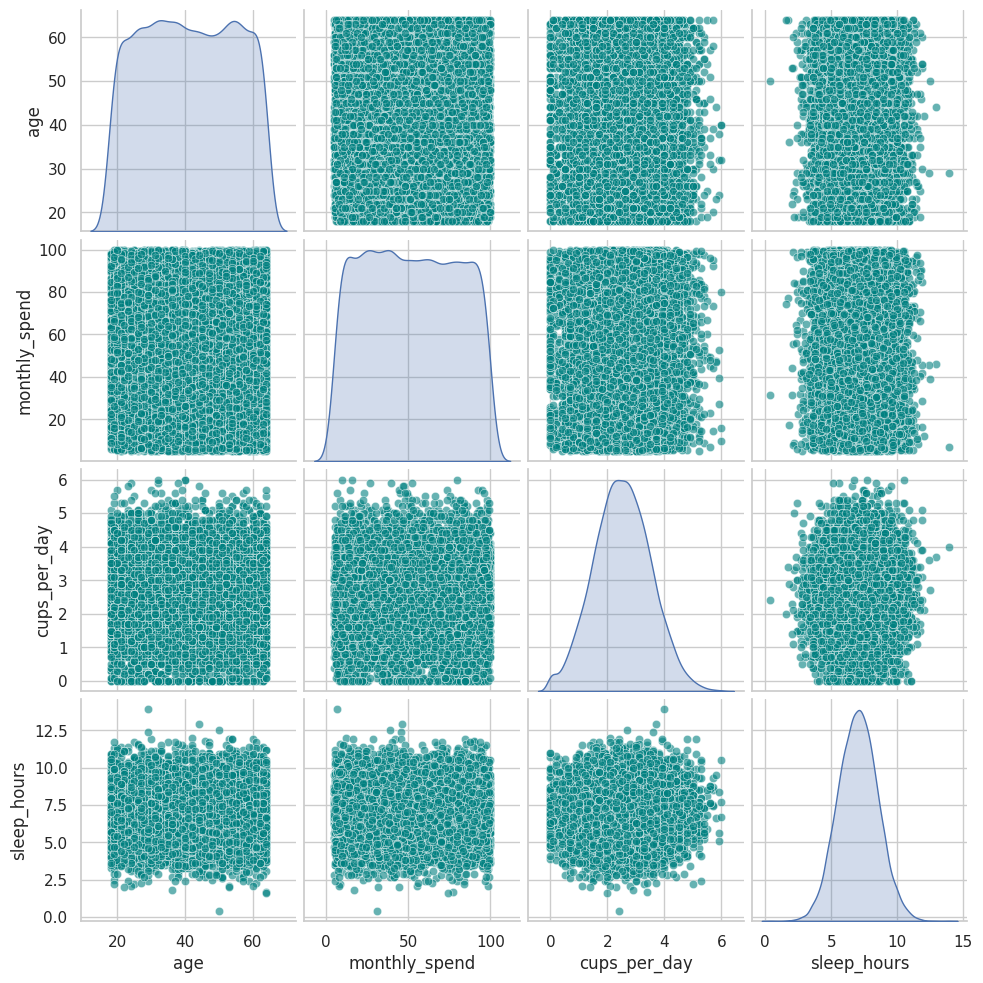

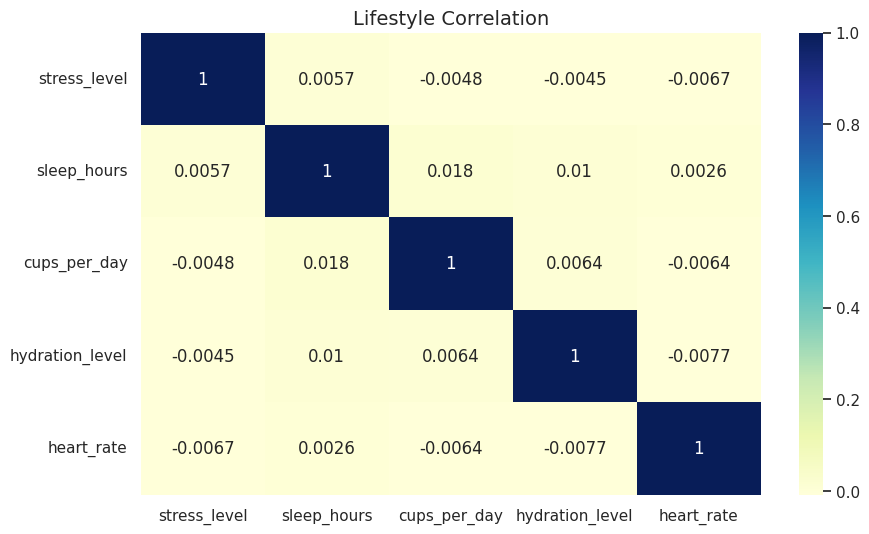

In [13]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

# Style
plt.style.use('default')
sns.set_theme(style="whitegrid")

# ================================
# 2. LOAD DATA
# ================================
# Replace with your file path

# ================================
# 3. BASIC INFO
# ================================
print(df.shape)
print(df.info())
print(df.describe())

# ================================
# 4. MISSING VALUES
# ================================
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

# ================================
# 5. NUMERICAL DISTRIBUTION
# ================================
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(18,12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Numerical Features Distribution", fontsize=18)
plt.show()

# ================================
# 6. CORRELATION HEATMAP
# ================================
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# ================================
# 7. COUNT PLOTS (CATEGORICAL)
# ================================
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols[:6]:  # limit to avoid too many plots
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f"{col} Distribution", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# ================================
# 8. AGE vs SPENDING
# ================================
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='age',
    y='monthly_spend',
    hue='gender',
    palette='cool'
)
plt.title("Age vs Monthly Spend", fontsize=14)
plt.show()

# ================================
# 9. INCOME vs SPENDING
# ================================
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='income_level',
    y='monthly_spend',
    palette='Set3'
)
plt.title("Income Level vs Monthly Spend", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# ================================
# 10. FAVORITE DRINK ANALYSIS
# ================================
plt.figure(figsize=(10,5))
top_drinks = df['favorite_drink'].value_counts().head(10)

sns.barplot(
    x=top_drinks.values,
    y=top_drinks.index,
    palette='magma'
)
plt.title("Top Favorite Drinks", fontsize=14)
plt.show()

# ================================
# 11. STRESS vs CAFFEINE
# ================================
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='stress_level',
    y='cups_per_day',
    palette='coolwarm'
)
plt.title("Stress Level vs Cups Per Day", fontsize=14)
plt.show()

# ================================
# 12. SLEEP vs CAFFEINE
# ================================
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='cups_per_day',
    hue='stress_level',
    palette='viridis'
)
plt.title("Sleep Hours vs Cups Per Day", fontsize=14)
plt.show()

# ================================
# 13. HOME vs CAFE RATIO
# ================================
plt.figure(figsize=(8,5))
sns.histplot(
    df['home_vs_cafe_ratio'],
    bins=30,
    kde=True,
    color='purple'
)
plt.title("Home vs Cafe Consumption Ratio", fontsize=14)
plt.show()

# ================================
# 14. SATISFACTION LEVEL DISTRIBUTION
# ================================
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='satisfaction_level',
    palette='cubehelix'
)
plt.title("Satisfaction Level Distribution", fontsize=14)
plt.show()

# ================================
# 15. MULTI-RELATION PAIRPLOT
# ================================
sns.pairplot(
    df[['age', 'monthly_spend', 'cups_per_day', 'sleep_hours']],
    diag_kind='kde',
    plot_kws={'alpha':0.6, 'color':'teal'}
)
plt.show()

# ================================
# 16. HEATMAP (LIFESTYLE IMPACT)
# ================================
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['stress_level','sleep_hours','cups_per_day','hydration_level','heart_rate']].corr(),
    annot=True,
    cmap='YlGnBu'
)
plt.title("Lifestyle Correlation", fontsize=14)
plt.show()

## Feature engineering


===== Logistic Regression =====
Accuracy : 0.1007
ROC-AUC  : 0.5068

===== Random Forest =====
Accuracy : 0.1047
ROC-AUC  : 0.4985

===== Gradient Boosting =====
Accuracy : 0.1120
ROC-AUC  : 0.5025


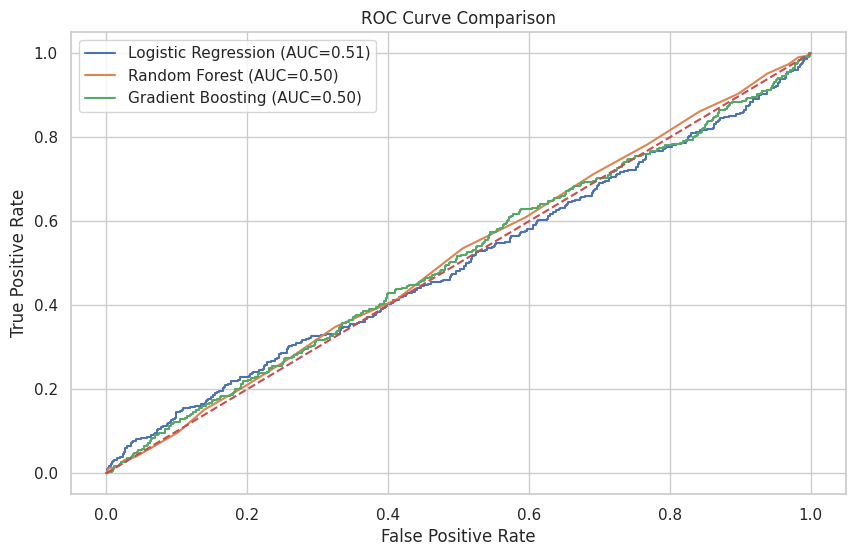


Final Comparison:

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.100667  0.506801
2    Gradient Boosting  0.112000  0.502479
1        Random Forest  0.104667  0.498453


In [14]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# ======================================
# 3. DEFINE TARGET
# ======================================
target = 'satisfaction_level'   # 🔥 change if needed
X = df.drop(columns=[target])
y = df[target]

# ======================================
# 4. HANDLE TARGET (MULTI-CLASS SAFE)
# ======================================
y = y.astype(str)  # ensure categorical

# ======================================
# 5. TRAIN TEST SPLIT (NO LEAKAGE)
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# 6. FEATURE TYPES
# ======================================
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# ======================================
# 7. PREPROCESSING PIPELINE
# (NO DATA LEAKAGE - inside pipeline)
# ======================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# ======================================
# 8. MODELS (NO SVM)
# ======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# ======================================
# 9. BINARIZE TARGET FOR ROC
# ======================================
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

# ======================================
# 10. TRAIN + EVALUATE
# ======================================
plt.figure(figsize=(10,6))

results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # ROC-AUC (multi-class)
    roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
    
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    
    results.append((name, acc, roc_auc))
    
    # ROC Curve (class 0 example)
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Plot ROC
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ======================================
# 11. FINAL RESULTS TABLE
# ======================================
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'ROC_AUC'])
print("\nFinal Comparison:\n")
print(results_df.sort_values(by='ROC_AUC', ascending=False))

## Thank  you..pls upvote!!!!!!!!!!!